Amishi Gupta

23/CS/048

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, warnings, pickle, json
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Embedding, GRU, Bidirectional,
                                     Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.19.0
GPU: []


In [16]:
DATA_PATH = '/content/drive/MyDrive/Amazon_Reviews.csv'
df = pd.read_csv(DATA_PATH, on_bad_lines='skip', engine='python')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (21214, 9)
Columns: ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [17]:
print(df.isnull().sum())
print('\nRating value counts:\n', df['Rating'].value_counts())

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

Rating value counts:
 Rating
Rated 1 out of 5 stars    13123
Rated 5 out of 5 stars     4528
Rated 4 out of 5 stars     1292
Rated 2 out of 5 stars     1227
Rated 3 out of 5 stars      885
Name: count, dtype: int64


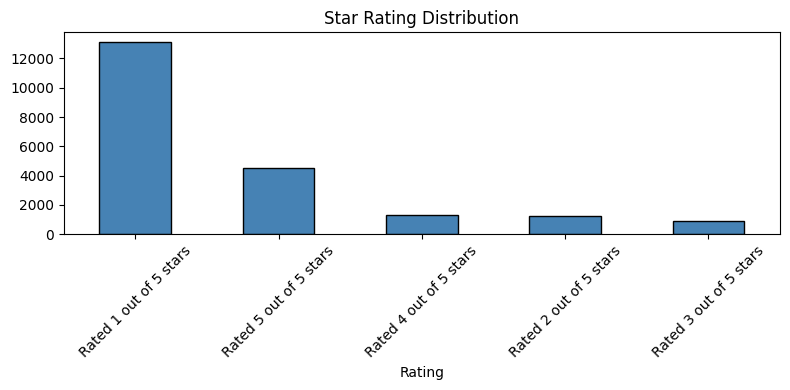

In [18]:
df['Rating'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black', figsize=(8,4))
plt.title('Star Rating Distribution'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

sentiment
Negative    14350
Positive     5820
Neutral       885
Name: count, dtype: int64


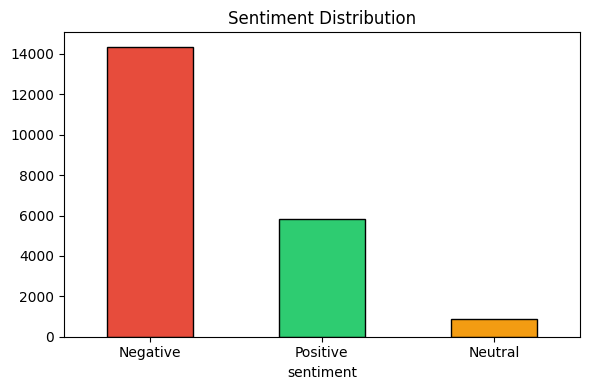

In [19]:
def extract_stars(s):
    m = re.search(r'(\d)', str(s))
    return int(m.group(1)) if m else None

df['stars'] = df['Rating'].apply(extract_stars)
df.dropna(subset=['stars', 'Review Text'], inplace=True)
df['stars'] = df['stars'].astype(int)

def to_sentiment(stars):
    if stars >= 4: return 'Positive'
    if stars == 3: return 'Neutral'
    return 'Negative'

df['sentiment'] = df['stars'].apply(to_sentiment)
print(df['sentiment'].value_counts())

colors = {'Positive':'#2ecc71','Neutral':'#f39c12','Negative':'#e74c3c'}
vc = df['sentiment'].value_counts()
vc.plot(kind='bar', color=[colors[s] for s in vc.index], edgecolor='black', figsize=(6,4))
plt.title('Sentiment Distribution'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

Dataset after cleaning: 21055


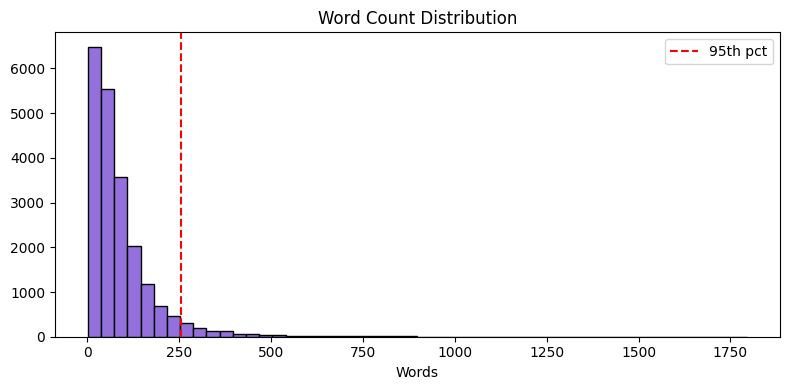

95th pct: 256 words


In [20]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df['text'] = (df['Review Title'].fillna('') + ' ' + df['Review Text'].fillna('')).apply(clean_text)
df = df[df['text'].str.len() > 10].reset_index(drop=True)
print(f'Dataset after cleaning: {len(df)}')

df['text_len'] = df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,4))
plt.hist(df['text_len'], bins=50, color='mediumpurple', edgecolor='black')
plt.axvline(df['text_len'].quantile(0.95), color='red', linestyle='--', label='95th pct')
plt.title('Word Count Distribution'); plt.xlabel('Words'); plt.legend()
plt.tight_layout(); plt.show()
print(f'95th pct: {df["text_len"].quantile(0.95):.0f} words')

In [21]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
NUM_CLASSES = len(le.classes_)
X = df['text'].values
y = df['label'].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Class mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
Train: 14738 | Val: 3158 | Test: 3159


In [22]:
VOCAB_SIZE = 20000
MAX_LEN    = 150
EMBED_DIM  = 128
GRU_UNITS  = 64
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
ACTUAL_VOCAB = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f'Vocab size: {ACTUAL_VOCAB}')
def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_train_enc = encode(X_train)
X_val_enc   = encode(X_val)
X_test_enc  = encode(X_test)
print('Encoded train shape:', X_train_enc.shape)

Vocab size: 20000
Encoded train shape: (14738, 150)


In [14]:
print(df.columns)
print(df.head())

Index(['clean_review', 'sentiment'], dtype='object')
Empty DataFrame
Columns: [clean_review, sentiment]
Index: []


In [23]:
def build_gru_model(vocab_size, embed_dim, max_len, gru_units, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len, name='embedding'),
        SpatialDropout1D(0.3),
        Bidirectional(GRU(gru_units, return_sequences=True,
                          dropout=0.2, recurrent_dropout=0.1), name='bigru'),
        GRU(gru_units // 2, dropout=0.2, recurrent_dropout=0.1, name='gru'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax', name='output'),
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_gru_model(ACTUAL_VOCAB, EMBED_DIM, MAX_LEN, GRU_UNITS, NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru (Bidirectional)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
cw_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw_arr))
print('Class weights:', {le.classes_[k]: round(v,3) for k,v in class_weights.items()})

Class weights: {'Negative': np.float64(0.489), 'Neutral': np.float64(7.936), 'Positive': np.float64(1.206)}


In [27]:
EPOCHS = 4
BATCH  = 64
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_gru_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]
history = model.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    class_weight=class_weights,
    callbacks=callbacks, verbose=1
)

Epoch 1/4
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.3093 - loss: 1.1209
Epoch 1: val_accuracy improved from None to 0.40912, saving model to /content/best_gru_model.keras

Epoch 1: finished saving model to /content/best_gru_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 161s 699ms/step - accuracy: 0.3768 - loss: 1.0798 - val_accuracy: 0.4091 - val_loss: 1.0287 - learning_rate: 0.0010
Epoch 2/4
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.4024 - loss: 1.0594
Epoch 2: val_accuracy did not improve from 0.40912
231/231 ━━━━━━━━━━━━━━━━━━━━ 199s 688ms/step - accuracy: 0.3730 - loss: 1.0690 - val_accuracy: 0.4050 - val_loss: 1.0782 - learning_rate: 0.0010
Epoch 3/4
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.3378 - loss: 1.0833
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.40912
231/231 ━━━━━━━━━━━━━━━━━━━━ 161s 699ms/step - accuracy: 0.3713 - loss: 1.0588 - val_accuracy: 0.3949 - va

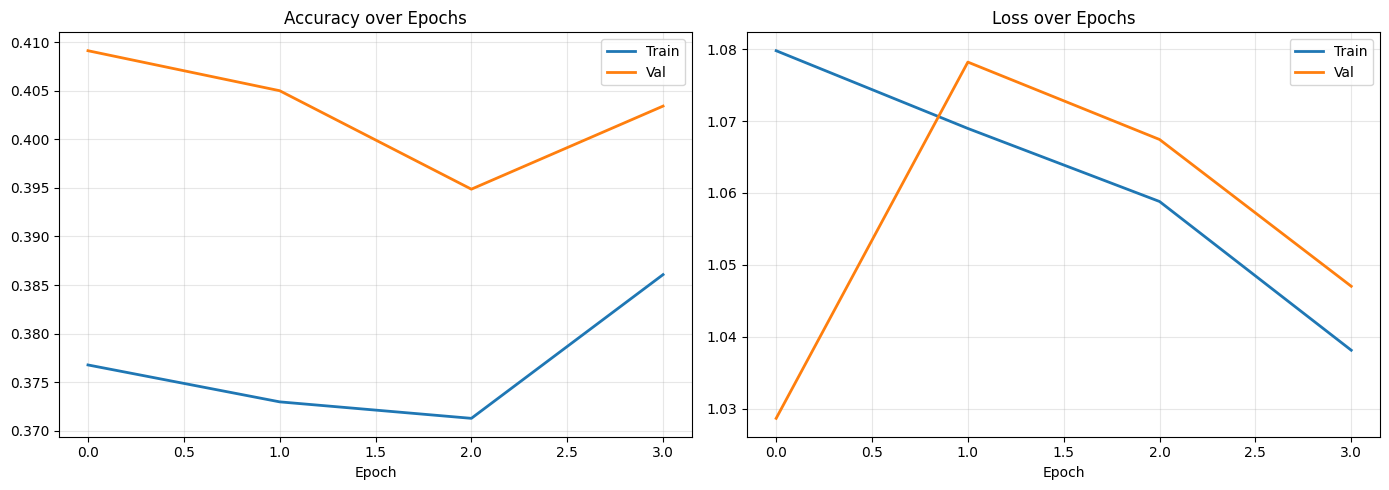

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (m, vm), title in zip(axes,
    [('accuracy','val_accuracy'),('loss','val_loss')],
    ['Accuracy over Epochs','Loss over Epochs']):
    ax.plot(history.history[m], label='Train', lw=2)
    ax.plot(history.history[vm], label='Val', lw=2)
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [29]:
model = load_model('/content/best_gru_model.keras')
y_pred = np.argmax(model.predict(X_test_enc, verbose=0), axis=1)
print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Weighted F1   : {f1_score(y_test, y_pred, average="weighted"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy : 0.4163
Weighted F1   : 0.3749

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.22      0.36      2153
     Neutral       0.00      0.00      0.00       133
    Positive       0.32      0.96      0.48       873

    accuracy                           0.42      3159
   macro avg       0.41      0.39      0.28      3159
weighted avg       0.71      0.42      0.37      3159



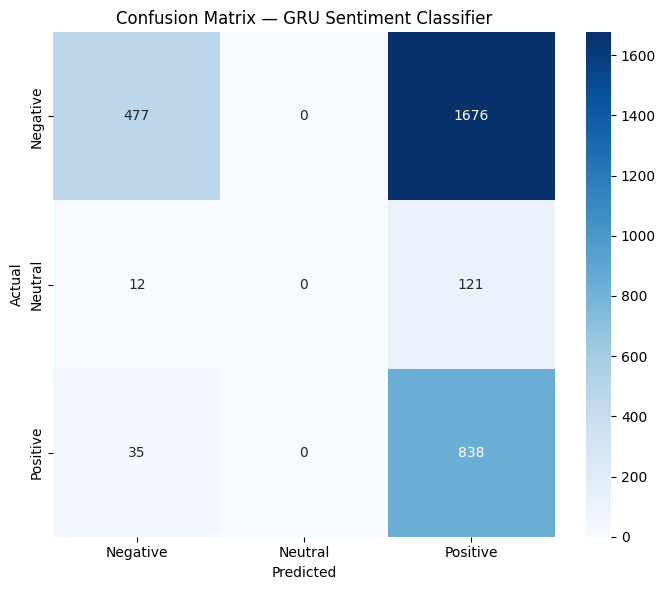

In [30]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — GRU Sentiment Classifier')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

In [32]:
def predict_sentiment(reviews):
    if isinstance(reviews, str): reviews = [reviews]
    cleaned = [clean_text(r) for r in reviews]
    enc     = encode(cleaned)
    probs   = model.predict(enc, verbose=0)
    rows = []
    for rev, prob in zip(reviews, probs):
        pred = le.classes_[np.argmax(prob)]
        conf = f'{prob.max()*100:.1f}%'
        rows.append({'Review': rev[:80], 'Predicted': pred, 'Confidence': conf})
    return pd.DataFrame(rows)

sample_review = [
    'Absolutely love this product! Works perfectly and arrived fast.',
]

predict_sentiment(sample_review)

,Review,Predicted,Confidence
0,Absolutely love this product! Works perfectly ...,Positive,36.4%
